In [2]:
import matplotlib.pyplot as plt

SA_RC = {
    # --- Figure ---
    'figure.figsize': (6, 4),
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'figure.autolayout': True,

    # --- Axes ---
    'axes.facecolor': 'white',
    'axes.edgecolor': '#444444',
    'axes.linewidth': 0.8,
    'axes.spines.top': True,  # both spines visible (commented-out removal kept)
    'axes.spines.right': True,
    'axes.labelsize': 12,
    'axes.labelcolor': 'black',
    'axes.titlelocation': 'center',

    # --- Grid ---
    'axes.grid': False,  # no grid in source plot

    # --- Ticks ---
    'xtick.labelsize': 12,
    'xtick.color': 'black',
    'xtick.direction': 'out',
    'ytick.labelsize': 10,
    'ytick.color': 'black',
    'ytick.direction': 'out',

    # --- Font ---
    'font.family': 'sans-serif',
    'font.serif': ['computer modern roman'],
    'font.sans-serif': ['Helvetica Neue LT Pro'],
    'font.size': 10,
    'text.color': 'black',
    'font.weight': '300', 'axes.labelweight': '500',

    # --- Patches (bars, legend swatches) ---
    'patch.edgecolor': 'black',
    'patch.linewidth': 0.7,
    'patch.force_edgecolor': True,

    # --- Legend ---
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'legend.framealpha': 0.0,  # transparent legend box
    'legend.edgecolor': '#444444',

    # --- Lines ---
    'lines.linewidth': 0.7,

    # --- Saving ---
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
}
plt.rcParams.update(SA_RC)
dir_paper_figure = r"D:\pykan\github\workflows\Hyein\figures_for_paper"

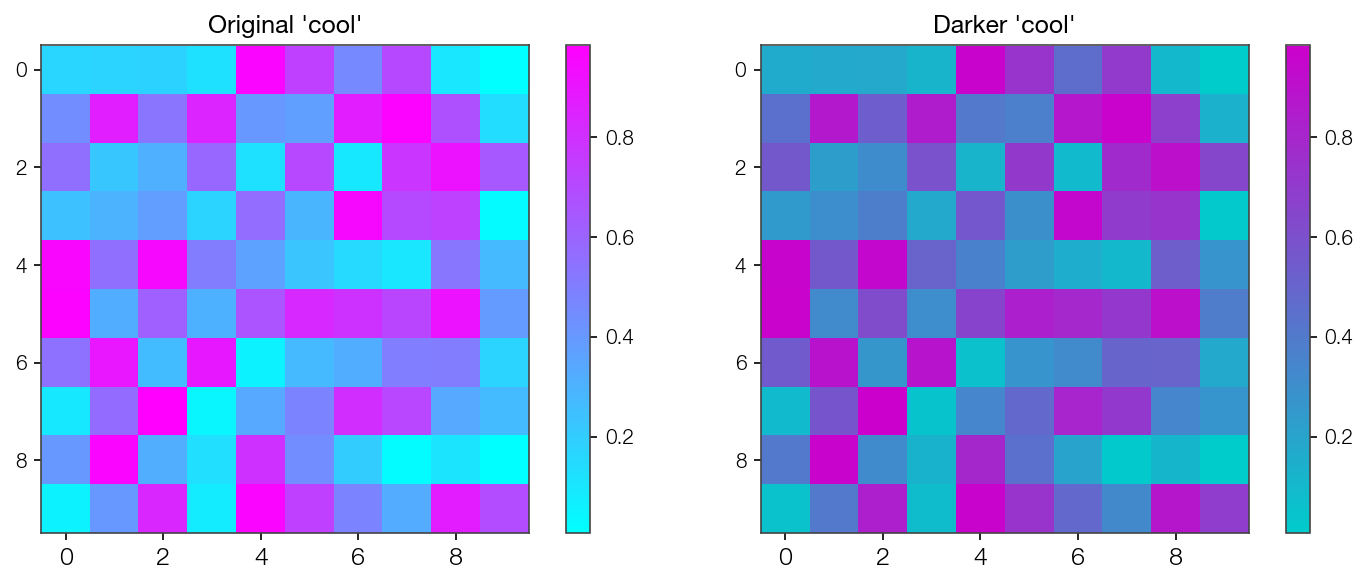

In [2]:
import matplotlib.colors as mcolors
import numpy as np

# 1. Retrieve the original colormap
orig_cmap = plt.get_cmap('cool')

# 2. Extract a continuous array of 256 colors from the map
# This returns an array of shape (256, 4) containing RGBA values
colors = orig_cmap(np.linspace(0, 1, 256))

# 3. Define the darkening factor (0.0 is pure black, 1.0 is original)
# 0.6 retains 60% of the original brightness
darken_factor = 0.8

# 4. Apply the factor to the RGB channels (indices 0, 1, 2)
# We leave the Alpha channel (index 3) untouched to preserve opacity
dark_colors = colors.copy()
dark_colors[:, :3] = dark_colors[:, :3] * darken_factor

# 5. Register the modified colors as a new colormap
darker_cmap = mcolors.LinearSegmentedColormap.from_list('cool_darker', dark_colors)

# --- Testing the Output ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
data = np.random.rand(10, 10)

# Original
im1 = ax1.imshow(data, cmap='cool')
ax1.set_title("Original 'cool'")
plt.colorbar(im1, ax=ax1)

# Darkened
im2 = ax2.imshow(data, cmap=darker_cmap)
ax2.set_title("Darker 'cool'")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

## Analytic Function

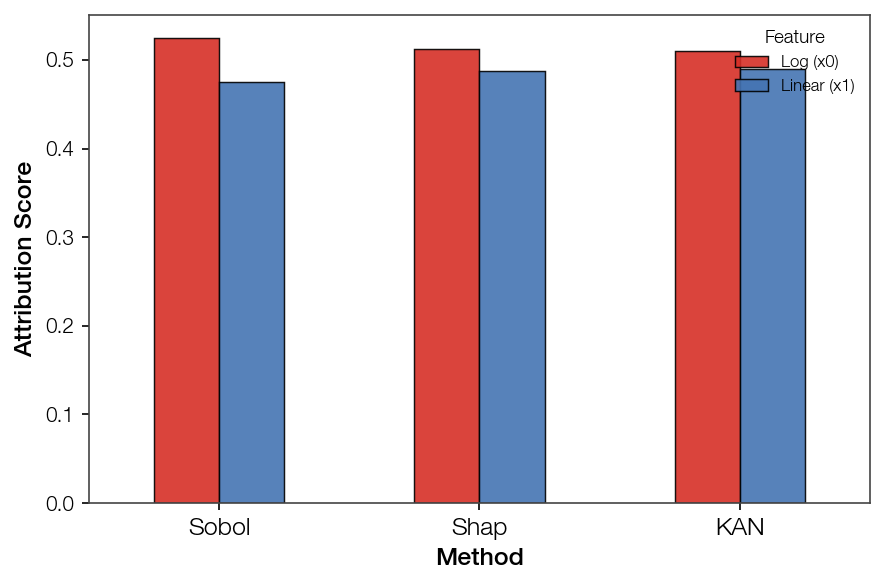

In [17]:
import pandas as pd
import os
import numpy as np

fun_analytic = 'logarithm'

dir_analytic = r"D:\pykan\github\workflows\Hyein\analytical_results"
file_sobol = os.path.join(dir_analytic, fun_analytic, "sobol_indices_global.csv")
file_shap = os.path.join(dir_analytic, fun_analytic, "shap_mean_abs_global.csv")
file_kan = os.path.join(dir_analytic, fun_analytic, "kan_models", f"{fun_analytic}_global_attribution_scores.csv")

df_sobol = pd.read_csv(file_sobol)
feat_names = df_sobol['Feature'].tolist()
s_sobol = df_sobol['First_Order (S1)'].tolist()

df_shap = pd.read_csv(file_shap)
s_shap = df_shap['Mean_Abs_SHAP'].tolist()

df_KAN = pd.read_csv(file_kan)
s_kan = df_KAN['Global_Attribution_Score'].tolist()

s_ALL = {
    'Feature': feat_names,
    'Sobol': s_sobol,
    'Shap': s_shap,
    'KAN': s_kan
}
df_all = pd.DataFrame(s_ALL)

numeric_cols = ['Sobol', 'SHAP', 'KAN']
df_all[numeric_cols] = df_all[numeric_cols] / df_all[numeric_cols].sum()
# 2. Reshape the data for plotting
# Set 'Feature' as the index and select the method columns
df_methods = df_all.set_index('Feature')[numeric_cols]

# Transpose the DataFrame so Methods become the rows (x-axis)
# and Features become the columns (individual bars per group)
df_transposed = df_methods.T

# 3. Create the plot using pandas built-in wrapper
# This automatically handles dynamic counts of features
num_feat = len(feat_names)
cmap = plt.get_cmap('RdYlBu')
custom_colors = [cmap(x) for x in np.linspace(0.1, 0.9, num_feat)]
ax = df_transposed.plot(kind='bar', rot=0, color=custom_colors, alpha=0.9)

# 4. Customize axes and labels
ax.set_xlabel('Method')
ax.set_ylabel('Attribution Score')
ax.legend(title='Feature')

# Adjust layout and display
plt.savefig(os.path.join(dir_analytic, fun_analytic, "VS_conventional.png"))
plt.savefig(os.path.join(dir_analytic, fun_analytic, "VS_conventional.svg"), format='svg')
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventional_{fun_analytic}.png"))
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventional_{fun_analytic}.svg"), format='svg')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


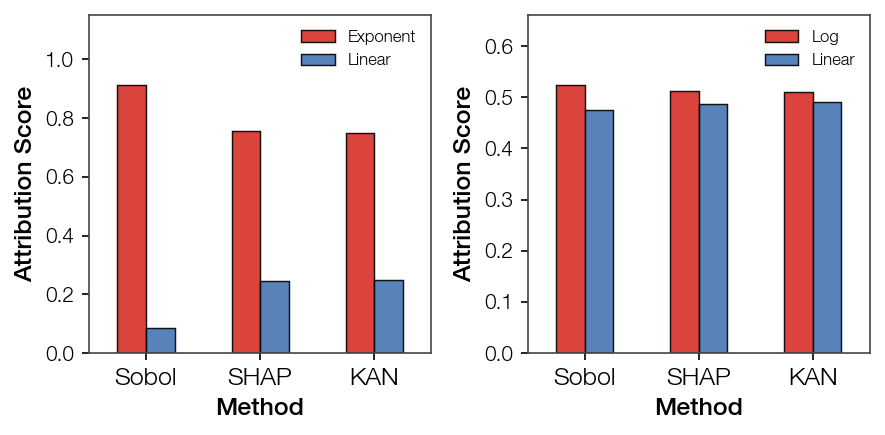

In [47]:
import pandas as pd
import os
import numpy as np

analytic_fun_list = ['exponential', 'logarithm']

def get_analytic_res(fun_analytic):
    dir_analytic = r"D:\pykan\github\workflows\Hyein\analytical_results"
    file_sobol = os.path.join(dir_analytic, fun_analytic, "sobol_indices_global.csv")
    file_shap = os.path.join(dir_analytic, fun_analytic, "shap_mean_abs_global.csv")
    file_kan = os.path.join(dir_analytic, fun_analytic, "kan_models", f"{fun_analytic}_global_attribution_scores.csv")

    files = [file_sobol, file_shap, file_kan]
    columns = ['First_Order (S1)', 'Mean_Abs_SHAP', 'Global_Attribution_Score']
    methods = ['Sobol', 'SHAP', 'KAN']

    dfs = [pd.read_csv(f) for f in files]
    dfs = [d.set_index('Feature') for d in dfs]
    s_ALL = [d[c] for d, c in zip(dfs, columns)]
    df_methods = pd.concat(s_ALL, axis=1)
    df_methods.columns = methods
    df_methods.sort_values('KAN', inplace=True, ascending=False)
    df_methods[methods] = df_methods[methods] / df_methods[methods].sum()

    df_methods.index = df_methods.index.str.replace(r'\s*\(.*?\)', '', regex=True)
    df_transposed = df_methods.T
    return df_transposed

def plot_analysis_res(name_data, ax, df):
    num_feat = len(df.columns)
    cmap = plt.get_cmap('RdYlBu')
    custom_colors = [cmap(x) for x in np.linspace(0.1, 0.9, num_feat)]

    df.plot(kind='bar', rot=0, color=custom_colors, alpha=0.9, ax=ax)

    # 4. Customize axes and labels
    ax.set_xlabel('Method')
    ax.set_ylabel('Attribution Score')
    ax.legend()
    y_min, y_max = ax.get_ylim()
    ax.set_ylim([0, y_max*1.2])
    # ax.set_title(name_data)

df_data = [get_analytic_res(fun) for fun in analytic_fun_list]
fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes_flat = axes.flatten()
for data, df_target, ax_target in zip(analytic_fun_list + data_list, df_data, axes_flat):
    plot_analysis_res(data, ax_target, df_target)

# Adjust layout and display
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_Analytic.png"))
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_Analytic.svg"), format='svg')
plt.savefig(os.path.join(dir_paper_figure, f"VS_conventionals_Analytic.eps"), format='eps')
plt.show()

## Pre-defined Dataset

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# Shared configuration
# ============================================================
ROOT_DIR           = r"D:\pykan\github\workflows\Hyein"
MODEL_DIR_TEMPLATE = os.path.join(ROOT_DIR, "material_kan_models", "{name_data}")

# Method label -> (filename pattern, column name in that csv).
# Patterns use {name_data} as a placeholder; uncomment ST to include it.
SOURCES = {
    'S1':   ("{name_data}_sobol_indices_salib.csv",       'S1'),
    # 'ST':   ("{name_data}_sobol_indices_owen.csv",      'ST'),
    'SHAP': ("{name_data}_shap_importance.csv",           'Mean_Abs_SHAP'),
    'KAN':  ("{name_data}_global_attribution_scores.csv", 'Global_Attribution_Score'),
}


# ============================================================
# Data loading
# ============================================================
def load_attribution_scores(name_data, sources=SOURCES):
    """Return a (features x methods) DataFrame, normalised so each column sums to 1
    and sorted by the KAN score (descending)."""
    model_dir = MODEL_DIR_TEMPLATE.format(name_data=name_data)

    def _load_series(method, fname_pat, col):
        fname = fname_pat.format(name_data=name_data)
        return (pd.read_csv(os.path.join(model_dir, fname))
                  .set_index('Feature')[col]
                  .rename(method))

    df = pd.concat(
        [_load_series(method, fname_pat, col)
         for method, (fname_pat, col) in sources.items()],
        axis=1,
    )

    df.index = (df.index
                .str.replace(r'\s*\(.*?\)', '', regex=True)
                .str.replace(r'\s*\[.*?\]', '', regex=True))

    return (df.sort_values('KAN', ascending=False)
              .pipe(lambda d: d / d.sum()))


# ============================================================
# Core: bar plot (handles BOTH standalone and subplot use)
# ------------------------------------------------------------
# If `ax` is None, a new figure is created and (if save=True) the figure
# is written to disk in the standard two locations and shown.
# If `ax` is provided, the plot is drawn into the given axes; no figure
# is created, no save, no plt.show() — the caller manages those.
# ============================================================
def plot_attribution_bars(df_methods, name_data, ax=None, save=True):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots()

    num_feat = len(df_methods)
    colors   = [plt.get_cmap('RdYlBu')(x) for x in np.linspace(0.1, 0.9, num_feat)]

    df_methods.T.plot(kind='bar', rot=0, color=colors, alpha=0.9, ax=ax)
    ax.set_xlabel('Method')
    ax.set_ylabel('Attribution Score')
    ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

    # Title only when used as a subplot; standalone figures get their context
    # from the surrounding cell output.
    if not standalone:
        ax.set_title(name_data, fontsize=10)

    legend_fontsize = None if standalone else 6
    if "CO2RR" in name_data:
        ax.legend(loc='upper right', fontsize=legend_fontsize)
        x_min, x_max = ax.get_xlim()
        ax.set_xlim([x_min, x_max * 1.15])
    else:
        ax.legend(ncol=3, fontsize=legend_fontsize)

    if standalone and save:
        model_dir = MODEL_DIR_TEMPLATE.format(name_data=name_data)
        for out_dir, base in [(model_dir,        f"{name_data}_VS_conventional"),
                              (dir_paper_figure, f"VS_conventionals_{name_data}")]:
            plt.savefig(os.path.join(out_dir, f"{base}.png"))
            plt.savefig(os.path.join(out_dir, f"{base}.svg"), format='svg')
    if standalone:
        plt.show()

    return ax


# ============================================================
# Core: rank-agreement metrics
# ------------------------------------------------------------
# Returns (rho_matrix, record).
#   rho_matrix : full pairwise Spearman rho DataFrame (after eps filter)
#   record     : flat dict with one row of headline metrics suitable for
#                pd.DataFrame([record]) aggregation across datasets
# ============================================================
def topk_overlap(s1, s2, k=3):
    """Fraction of top-k features shared between two score Series."""
    return len(set(s1.nlargest(k).index) & set(s2.nlargest(k).index)) / k


def compute_rank_metrics(df_methods, name_data=None, eps=0.001, ref='KAN', k=3,
                         verbose=True, save=False):
    mask_drop = (df_methods < eps).all(axis=1)
    n_dropped = int(mask_drop.sum())
    df_filt   = df_methods.loc[~mask_drop] if n_dropped else df_methods

    if verbose:
        if n_dropped:
            print(f"Dropping {n_dropped} feature(s) below eps={eps} in all methods:")
            print(df_methods[mask_drop].round(4).to_string())
        else:
            print(f"All features are above eps={eps} in at least one method.")

    methods = df_filt.columns.tolist()
    rho = pd.DataFrame(
        [[spearmanr(df_filt[m1], df_filt[m2])[0] for m2 in methods] for m1 in methods],
        index=methods, columns=methods,
    )

    baselines = [m for m in methods if m != ref]
    record = {
        'Dataset':    name_data,
        'n_features': len(df_methods),
        'n_dropped':  n_dropped,
    }
    for m in baselines:
        record[f'rho_{ref}_vs_{m}']    = rho.loc[ref, m]
        record[f'top{k}_{ref}_vs_{m}'] = topk_overlap(df_filt[ref], df_filt[m], k=k)

    if verbose:
        summary_df = pd.DataFrame({
            'rho':     pd.Series({m: record[f'rho_{ref}_vs_{m}']    for m in baselines}),
            f'top{k}': pd.Series({m: record[f'top{k}_{ref}_vs_{m}'] for m in baselines}),
        }).round(3)
        print(f"\n{ref} vs. baselines (eps={eps}, n_features kept = {len(df_filt)}):")
        print(summary_df.to_string())

    if save and name_data is not None:
        model_dir = MODEL_DIR_TEMPLATE.format(name_data=name_data)
        rho.to_csv(os.path.join(model_dir, f"{name_data}_spearman_corr.csv"))

    return rho, record


# ============================================================
# Orchestrators
# ------------------------------------------------------------
# Both share `plot_attribution_bars` and `compute_rank_metrics`.
# ============================================================
def analyze_dataset(name_data, eps=0.001, k=3, save=True):
    """Single-dataset: standalone bar plot + verbose metrics summary."""
    print(f"=== {name_data} ===")
    df_methods = load_attribution_scores(name_data)
    plot_attribution_bars(df_methods, name_data, save=save)             # standalone
    compute_rank_metrics(df_methods, name_data, eps=eps, k=k,
                         verbose=True, save=save)
    return df_methods


def analyze_dataset_list(data_list, eps=0.001, k=3, ref='KAN',
                         ncols=3, save=True, combined_name='all_datasets'):
    """Multi-dataset: shared subplot figure + combined metrics CSV."""
    n     = len(data_list)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.5 * ncols, 3.5 * nrows),
                             constrained_layout=True)
    axes_flat = np.atleast_1d(axes).flatten()

    records = []
    for ax, name_data in zip(axes_flat, data_list):
        print(f"=== {name_data} ===")
        df_methods = load_attribution_scores(name_data)
        plot_attribution_bars(df_methods, name_data, ax=ax, save=False)  # subplot
        _, record = compute_rank_metrics(df_methods, name_data, eps=eps,
                                         ref=ref, k=k, verbose=False, save=False)
        records.append(record)

    for ax in axes_flat[n:]:
        ax.axis('off')

    if save:
        plt.savefig(os.path.join(dir_paper_figure, f"{combined_name}.png"))
        plt.savefig(os.path.join(dir_paper_figure, f"{combined_name}.svg"), format='svg')
    plt.show()

    df_metrics = pd.DataFrame(records)
    print(f"\n=== Combined metrics across {n} datasets (eps={eps}, k={k}) ===")
    print(df_metrics.to_string(index=False, float_format='{:.3f}'.format))

    if save:
        csv_path = os.path.join(dir_paper_figure, f"{combined_name}_metrics.csv")
        df_metrics.to_csv(csv_path, index=False)
        print(f"\nMetrics saved to: {csv_path}")

    return df_metrics

=== ITHH4500 ===


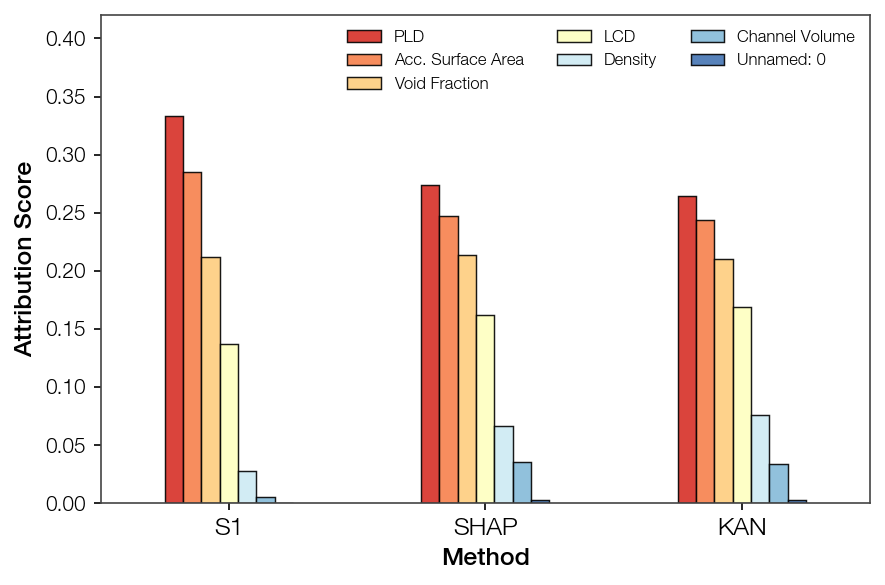

All features are above eps=0.001 in at least one method.

KAN vs. baselines (eps=0.001, n_features kept = 7):
      rho  top3
S1    1.0   1.0
SHAP  1.0   1.0


In [52]:
df = analyze_dataset('ITHH4500')

=== CrossedBarrel ===
=== AgNP ===
=== P3HT ===
=== ITH4500 ===
=== ITHH4500 ===
=== CO2RRLCA ===
=== CO2RRNPV ===
=== CO2RRMSP ===
=== CO2HPx10 ===


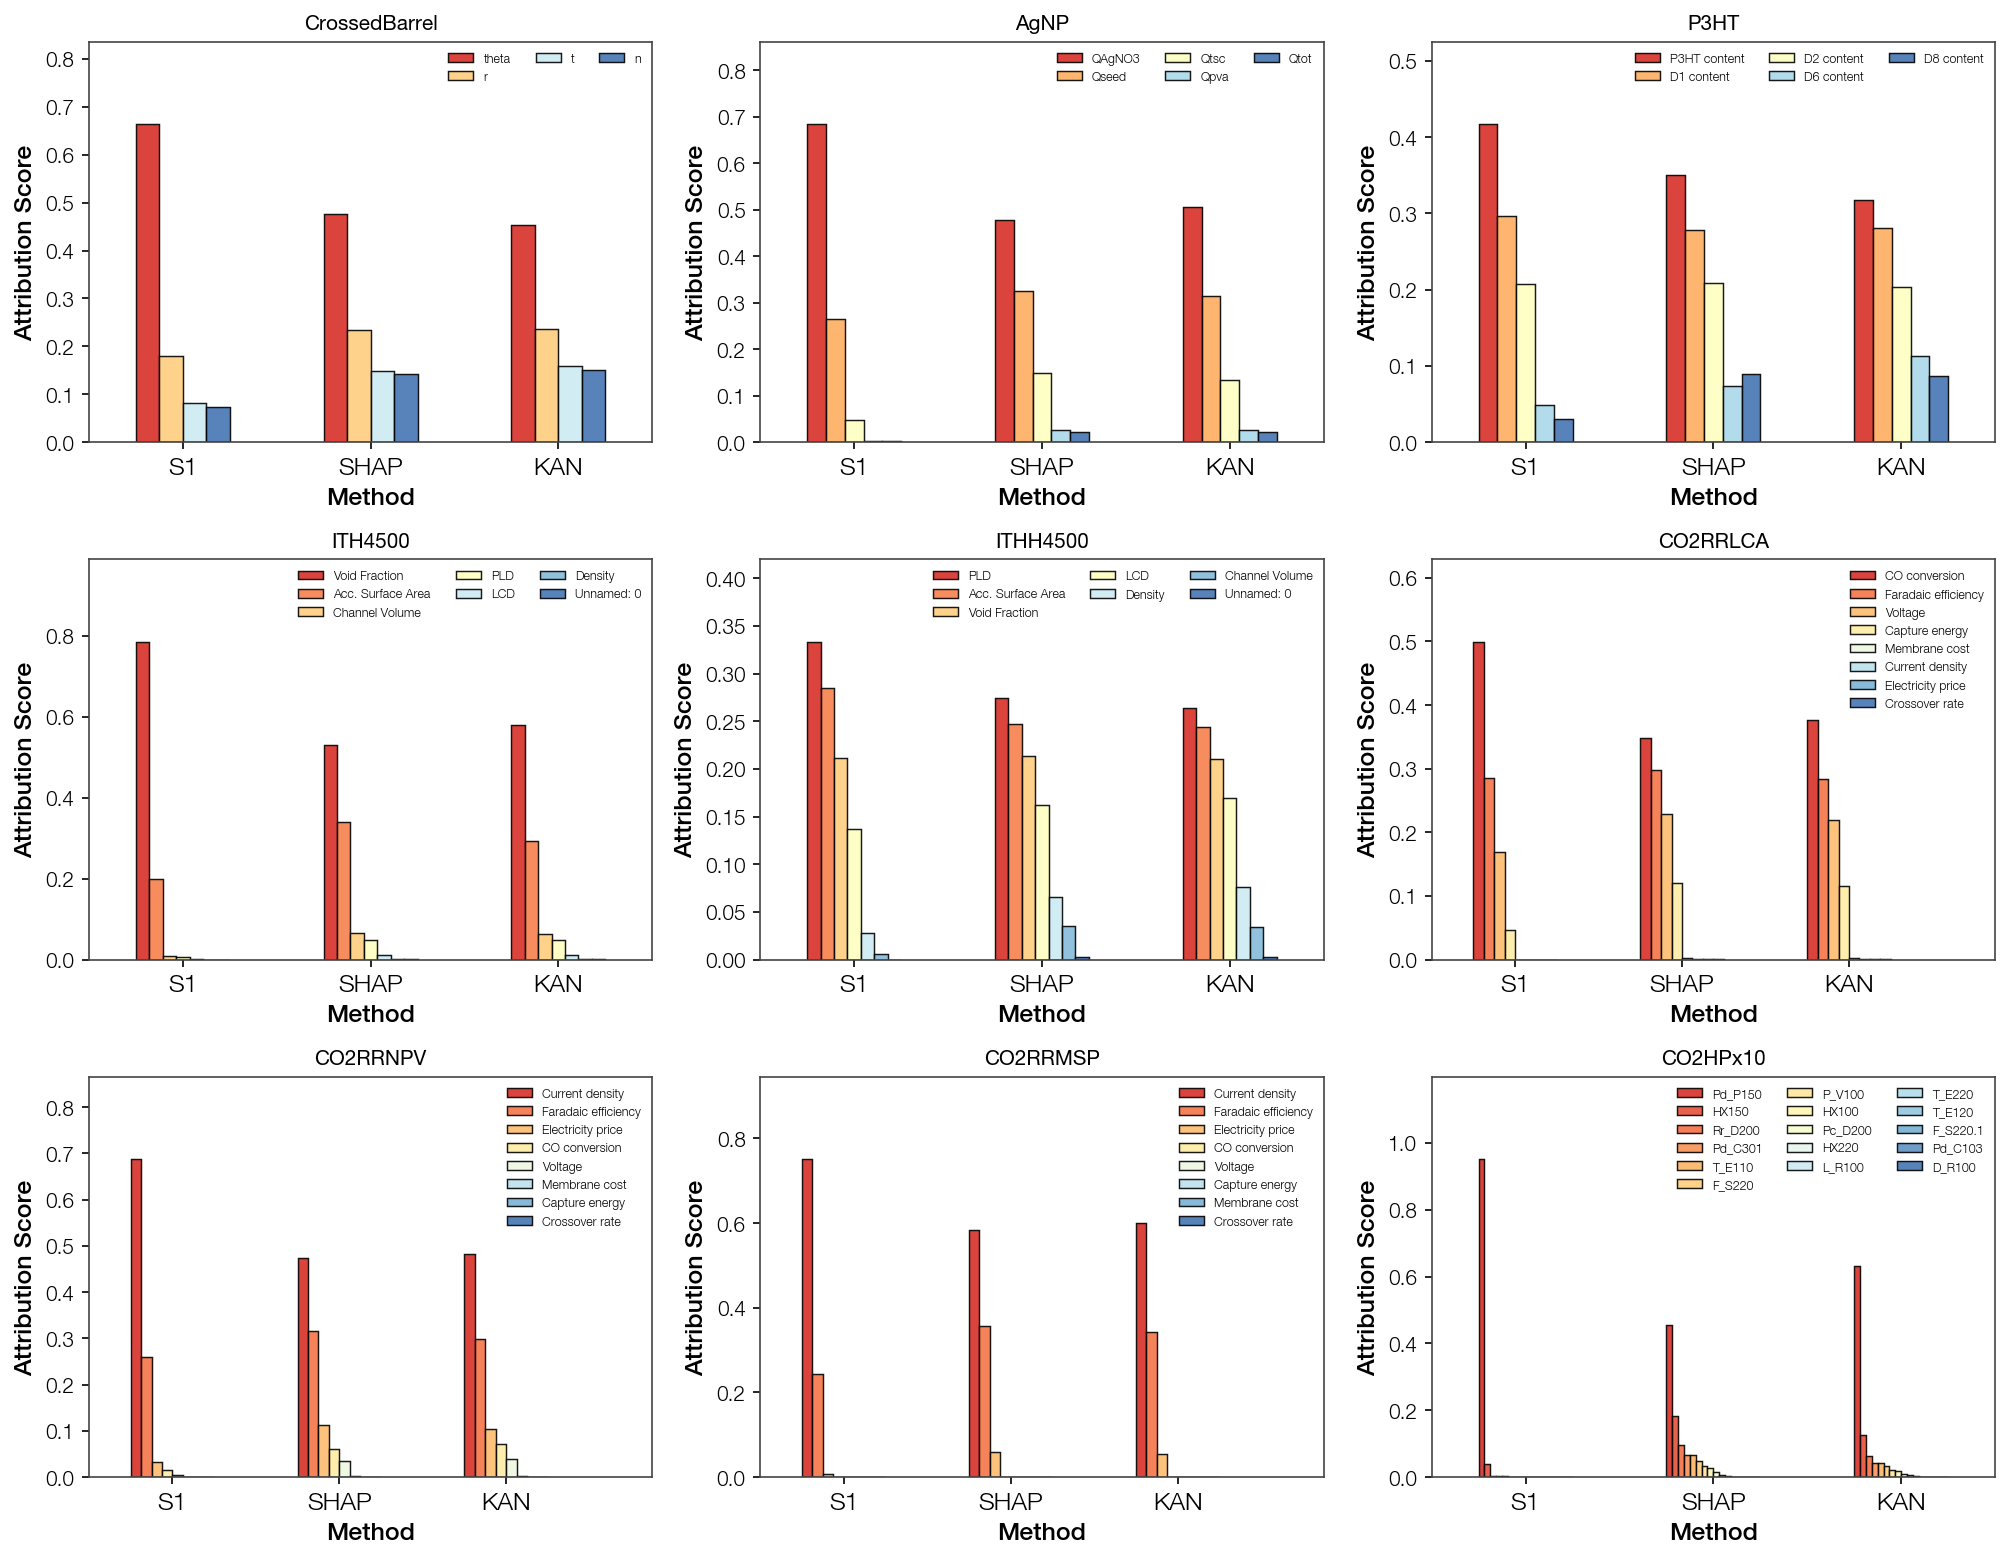


=== Combined metrics across 9 datasets (eps=0.001, k=3) ===
      Dataset  n_features  n_dropped  rho_KAN_vs_S1  top3_KAN_vs_S1  rho_KAN_vs_SHAP  top3_KAN_vs_SHAP
CrossedBarrel           4          0          1.000           1.000            1.000             1.000
         AgNP           5          0          1.000           1.000            1.000             1.000
         P3HT           5          0          1.000           1.000            0.900             1.000
      ITH4500           7          0          0.964           1.000            1.000             1.000
     ITHH4500           7          0          1.000           1.000            1.000             1.000
     CO2RRLCA           8          2          1.000           1.000            1.000             1.000
     CO2RRNPV           8          2          1.000           1.000            1.000             1.000
     CO2RRMSP           8          5          1.000           1.000            1.000             1.000
     CO2HPx1

In [56]:
data_list = [
    'CrossedBarrel',
    'AgNP',
    'P3HT',
    'ITH4500',
    'ITHH4500',
    'CO2RRLCA',
    'CO2RRNPV',
    'CO2RRMSP',
    'CO2HPx10',
]

df_metrics = analyze_dataset_list(data_list, eps=0.001, k=3,
                                  combined_name='VS_conventionals_All')